In [1]:
import numpy as np
import scipy.optimize 
import matplotlib.pyplot as plt

In [2]:
dataset = np.loadtxt('../trainData.txt', delimiter=',')
D=dataset[:,:6].T
L=dataset[:,6]

labels={
    1:"True",
    0:"False"
}

In [3]:
def getRow(vet):
    return vet.reshape((1, vet.size))
def getCol(vet):
     return vet.reshape((vet.size, 1))
def getMu(D):
    return D.sum(axis=1)/D.shape[1]

In [ ]:
def split_db_2to1(D, L, seed=0):
    nTrain = int(D.shape[1]*2.0/3.0)
    np.random.seed(seed)
    idx = np.random.permutation(D.shape[1])
    idxTrain = idx[0:nTrain]
    idxTest = idx[nTrain:]
    DTR = D[:, idxTrain]
    DVAL = D[:, idxTest]
    LTR = L[idxTrain]
    LVAL = L[idxTest]
    return (DTR, LTR), (DVAL, LVAL)

(DTR, LTR), (DVAL, LVAL)=split_db_2to1(D,L,0)

In [5]:
def get_confusion_mat(predictions,L):
    labels=np.unique(L)
    M=np.zeros((len(labels),len(labels)))

    predictions_int = np.array(predictions).astype(int)
    L_int = np.array(L).astype(int)

    for i in range(len(predictions_int)):
        M[predictions_int[i]][L_int[i]]+=1
    
    return M
def DCF_u(predictions,L,prior,Cfn,Cfp):
    C=np.array([[0,Cfn],[Cfp,0]])
    M=get_confusion_mat(predictions,L)
    cols_sum=np.sum(M,axis=0)
    R=M/cols_sum 
    expected_cost_per_class=np.sum(R*C,axis=0)
    prior_array = np.array([1 - prior, prior])
    DCFu=np.sum(expected_cost_per_class * prior_array)
    return DCFu

def DCF_norm(predictions,L,prior,Cfn,Cfp):
    B_dummy=min(prior*Cfn,(1-prior)*Cfp)
    dcf_u=DCF_u(predictions,L,prior,Cfn,Cfp)
    return dcf_u/B_dummy

def get_bayes_decision(llr,pi,Cfn,Cfp):
    pi_Ht=pi
    pi_Hf=1-pi
    t = -np.log((pi_Ht * Cfn) / (pi_Hf * Cfp))
    predictions=np.where(llr>t,1,0)

    return predictions

def compute_min_dcf(llr, L, pi, Cfn, Cfp):
    # Ordinamento degli score (LLR) per ricavare s_1...s_M
    sorted_llr = np.sort(llr)
    
    # Creazione del vettore delle soglie includendo gli estremi -inf e +inf
    thresholds = np.concatenate([np.array([-np.inf]), sorted_llr, np.array([np.inf])])
    
    # Inizializzazione del minimo a un valore infinitamente grande
    min_dcf = np.inf
    
    # Iterazione su tutte le possibili soglie t
    for t in thresholds:
        # Calcolo delle predizioni basate sulla soglia corrente
        predictions = np.where(llr > t, 1, 0)

        # Calcolo della DCF normalizzata
        dcf_n = DCF_norm(predictions,L,pi,Cfn,Cfp)
        
        # Aggiornamento del valore minimo se la soglia corrente risulta più performante
        if dcf_n < min_dcf:
            min_dcf = dcf_n
            
    return min_dcf

In [6]:
def train_SVM(DTR,LTR,C,K):
    ZTR=LTR*2-1
    N=DTR.shape[1]
    ones=np.ones((1,N))*K
    D=np.vstack([DTR,ones])
    G=D.T@D
    H=getCol(ZTR)*getRow(ZTR) * G

    def fOpt(alpha):
        Ha = H @ alpha
        loss = 0.5 * alpha.T @ Ha - alpha.sum()
        grad = Ha - np.ones(alpha.size)
        return loss, grad
    
    x0=np.zeros(N)
    alpha, _, _ = scipy.optimize.fmin_l_bfgs_b(
        func=fOpt,
        x0=x0,
        approx_grad=False,
        bounds=[(0, C) for _ in range(N)],
        factr=np.nan,
        pgtol=1e-5
    )
    wb = D @ (alpha * ZTR)
    w = wb[:-1]
    b = wb[-1]
    
    dual_loss,_=fOpt(alpha)
    val=1-(ZTR*(wb.T @ D))
    primal_loss=1/2*(wb.T @ wb) + C*np.where(val>0,val,0).sum()
    print(f"Primal Loss : {primal_loss} - Dual Loss : {-dual_loss}")
    return alpha,w, b



================================= K: 1 C: 1e-05==============================================================
Primal Loss : 0.04 - Dual Loss : -0.0
Error Rate: 50.4%
DCF min: 1.0
Actual DCF:1.0

================================= K: 1 C: 3.1622776601683795e-05==============================================================
Primal Loss : 0.11935334583814561 - Dual Loss : 0.11935334583814565
Error Rate: 9.2%
DCF min: 0.36199116743471577
Actual DCF:1.0

================================= K: 1 C: 0.0001==============================================================
Primal Loss : 0.3290170090801559 - Dual Loss : 0.3290170090801561
Error Rate: 9.2%
DCF min: 0.36397529441884274
Actual DCF:1.0

================================= K: 1 C: 0.00031622776601683794==============================================================
Primal Loss : 0.7734635862222929 - Dual Loss : 0.7734635848556493
Error Rate: 9.2%
DCF min: 0.36199116743471577
Actual DCF:0.9990079365079365

================================= K: 1 

Text(0, 0.5, 'DCF value')

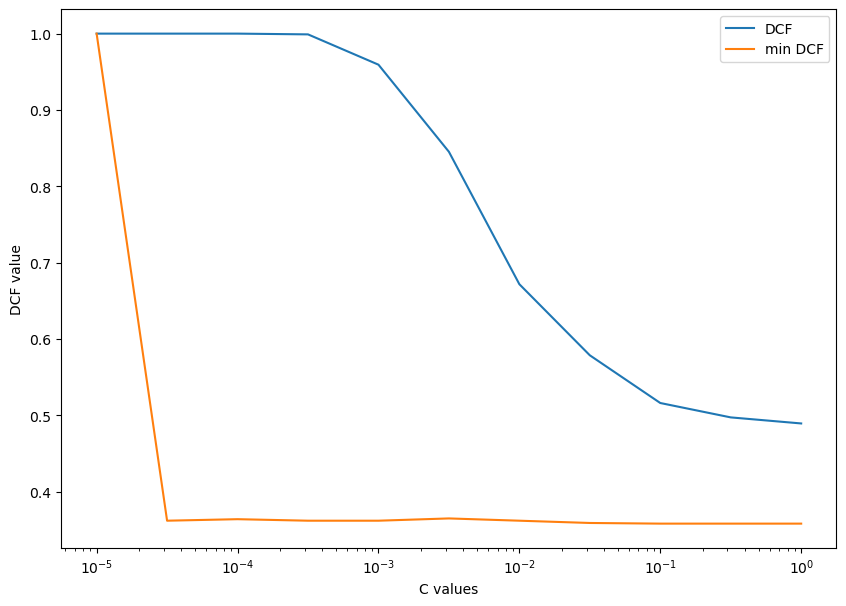

In [35]:
C=np.logspace(-5, 0, 11)
dcf=[]
mindcf=[]
pi_T=0.1
for c in C:
    print(f"================================= K: {1} C: {c}==============================================================")
    alpha,w,b=train_SVM(DTR,LTR,c,1)
    s=w.T @ DVAL + b
    predictions=s >0
    error_rate=np.mean(predictions != LVAL)
    min_dcf=compute_min_dcf(s,LVAL,pi_T,1,1)

    predictions_bayes = get_bayes_decision(s, pi_T, 1, 1)
    act_dcf = DCF_norm(predictions_bayes, LVAL, pi_T, 1, 1)
    dcf.append(act_dcf)
    mindcf.append(min_dcf)

    print(f"Error Rate: {error_rate * 100:.1f}%")
    print(f"DCF min: {min_dcf}")
    print(f"Actual DCF:{act_dcf}\n")

    print(f"==================================================================================================")


plt.figure(figsize=(10, 7))
plt.xscale('log')
plt.plot(C, dcf, label='DCF')
plt.plot(C, mindcf, label='min DCF')
plt.legend()
plt.xlabel("C values")
plt.ylabel("DCF value")

### Con DTR Centrato

Observation with DTR Centered
================================= K: 1 C: 1e-05==============================================================
Primal Loss : 0.04 - Dual Loss : -0.0
Error Rate: 50.4%
DCF min: 1.0
Actual DCF:1.0

================================= K: 1 C: 3.1622776601683795e-05==============================================================
Primal Loss : 0.11935315604413956 - Dual Loss : 0.11935315604413961
Error Rate: 9.2%
DCF min: 0.36199116743471577
Actual DCF:1.0

================================= K: 1 C: 0.0001==============================================================
Primal Loss : 0.3290156194724058 - Dual Loss : 0.3290156194724058
Error Rate: 9.2%
DCF min: 0.36397529441884274
Actual DCF:1.0

================================= K: 1 C: 0.00031622776601683794==============================================================
Primal Loss : 0.7734422455643782 - Dual Loss : 0.7734422455643779
Error Rate: 9.3%
DCF min: 0.36298323092677925
Actual DCF:0.9990079365079365

=========

Text(0, 0.5, 'DCF value')

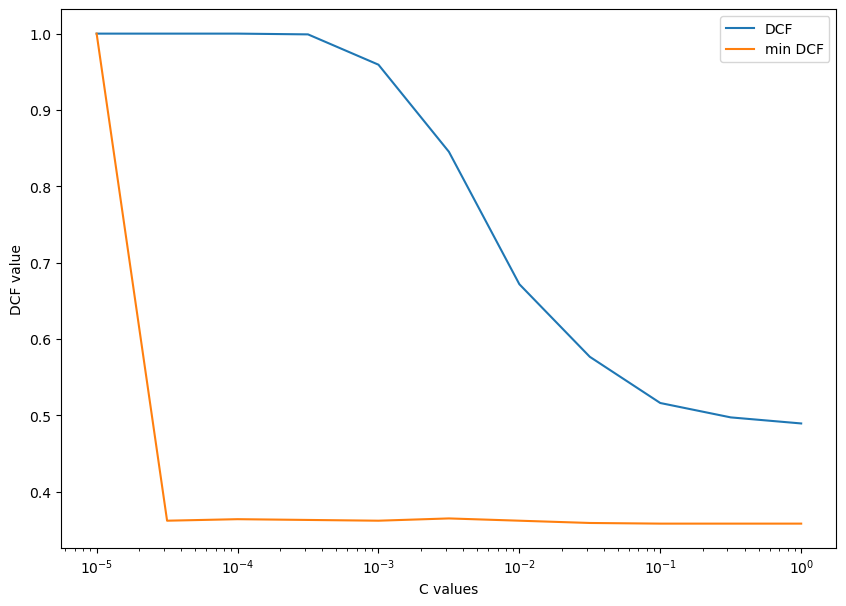

In [34]:
mean=getCol(getMu(DTR))
DTR_centered=DTR-mean
DVAL_centered=DVAL-mean
C=np.logspace(-5, 0, 11)
dcf=[]
mindcf=[]
pi_T=0.1
print("Observation with DTR Centered")
for c in C:
   

    print(f"================================= K: {1} C: {c}==============================================================")
    alpha,w,b=train_SVM(DTR_centered,LTR,c,1)
    s=w.T @ DVAL_centered + b
    predictions=s >0
    error_rate=np.mean(predictions != LVAL)
    min_dcf=compute_min_dcf(s,LVAL,pi_T,1,1)

    predictions_bayes = get_bayes_decision(s, pi_T, 1, 1)
    act_dcf = DCF_norm(predictions_bayes, LVAL, pi_T, 1, 1)
    dcf.append(act_dcf)
    mindcf.append(min_dcf)

    print(f"Error Rate: {error_rate * 100:.1f}%")
    print(f"DCF min: {min_dcf}")
    print(f"Actual DCF:{act_dcf}\n")

    print(f"==================================================================================================")


plt.figure(figsize=(10, 7))
plt.xscale('log')
plt.plot(C, dcf, label='DCF')
plt.plot(C, mindcf, label='min DCF')
plt.legend()
plt.xlabel("C values")
plt.ylabel("DCF value")

In [8]:
def polygrad_d(d,D1,D2,c):
    return (D1.T @ D2 + c) ** d
def KRB(D1, D2, gamma):
    # Calcolo delle norme al quadrato delle colonne per il primo dataset
    # Il reshape(-1, 1) assicura che il risultato sia un vettore colonna
    D1_norm2 = (D1 ** 2).sum(axis=0).reshape(-1, 1)
    
    # Calcolo delle norme al quadrato delle colonne per il secondo dataset
    # Il reshape(1, -1) assicura che il risultato sia un vettore riga
    D2_norm2 = (D2 ** 2).sum(axis=0).reshape(1, -1)
    
    # Calcolo della matrice delle distanze al quadrato sfruttando il broadcasting
    dist2 = D1_norm2 + D2_norm2 - 2 * (D1.T @ D2)
    
    # Applicazione dell'esponenziale scalato per gamma
    return np.exp(-gamma * dist2)

def regular_kernel(kernel,xi):
    return kernel+xi

def train_kernel_poly_SVM(C, DTR, LTR,xi,d,c):
    N = DTR.shape[1]
    ZTR = LTR * 2 - 1
    
    
    kernel_reg=regular_kernel(polygrad_d(d,DTR,DTR,c),xi)
    
    H = getCol(ZTR) * getRow(ZTR) * kernel_reg

    def fOpt(alpha):
        Ha = H @ alpha
        loss = 0.5 * alpha.T @ Ha - alpha.sum()
        grad = Ha - np.ones(alpha.size)
        return loss, grad

    x0 = np.zeros(N)
    alpha, _, _ = scipy.optimize.fmin_l_bfgs_b(
        func=fOpt,
        x0=x0,
        approx_grad=False,
        bounds=[(0, C) for _ in range(N)],
        factr=np.nan,
        pgtol=1e-5
    )
    
    
    dual_loss,_=fOpt(alpha)
    primal_loss=0.5*alpha.T @(H@alpha)+C*np.maximum(0,1-H@alpha).sum()
    print(f"Primal Loss : {primal_loss} - Dual Loss : {-dual_loss}")
    return alpha


def train_kernel_KRB(K, C, DTR, LTR,xi,gamma):
    N = DTR.shape[1]
    ZTR = LTR * 2 - 1
    
    
    kernel_reg=regular_kernel(KRB(DTR,DTR,gamma),xi)
    
    H = getCol(ZTR) * getRow(ZTR) * kernel_reg

    def fOpt(alpha):
        Ha = H @ alpha
        loss = 0.5 * alpha.T @ Ha - alpha.sum()
        grad = Ha - np.ones(alpha.size)
        return loss, grad

    x0 = np.zeros(N)
    alpha, _, _ = scipy.optimize.fmin_l_bfgs_b(
        func=fOpt,
        x0=x0,
        approx_grad=False,
        bounds=[(0, C) for _ in range(N)],
        factr=np.nan,
        pgtol=1e-5
    )
    
    
    dual_loss,_=fOpt(alpha)
    primal_loss=0.5*alpha.T @(H@alpha)+C*np.maximum(0,1-H@alpha).sum()
    print(f"Primal Loss : {primal_loss} - Dual Loss : {-dual_loss}")
    return alpha

================================= K: 0 Poly d=2==============================================================
================================= c=1e-05==============================================================
Primal Loss : 0.04 - Dual Loss : -0.0
Error Rate: 50.4%
DCF min: 1.0
Actual DCF:1.0

================================= c=3.1622776601683795e-05==============================================================
Primal Loss : 0.10765596015908384 - Dual Loss : 0.1076559599080082
Error Rate: 7.8%
DCF min: 0.24548771121351765
Actual DCF:1.0

================================= c=0.0001==============================================================
Primal Loss : 0.25444498918892555 - Dual Loss : 0.2544449871690707
Error Rate: 7.4%
DCF min: 0.2512960829493087
Actual DCF:1.0

================================= c=0.00031622776601683794==============================================================
Primal Loss : 0.5636608281252542 - Dual Loss : 0.5636608188562158
Error Rate: 7.2%
DCF min: 0.250

Text(0, 0.5, 'DCF value')

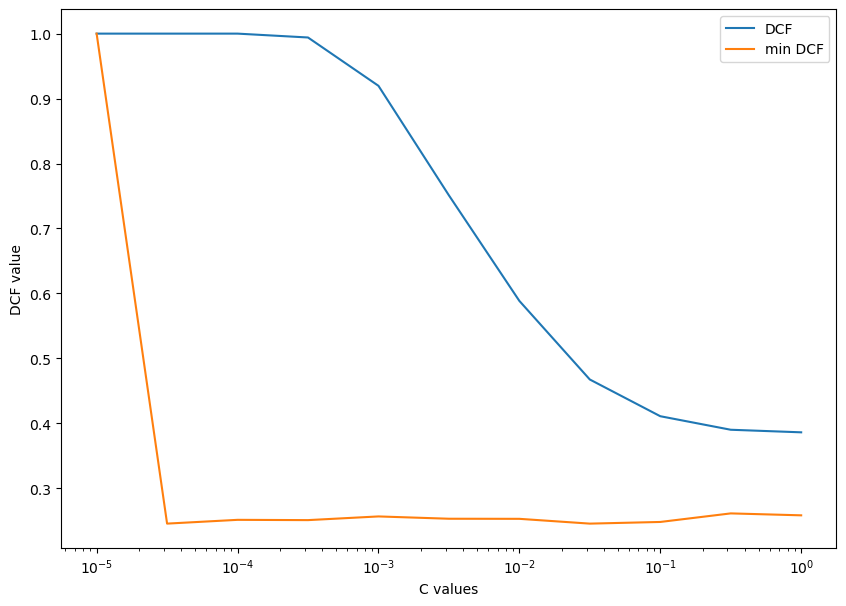

In [33]:
d=2
xi=0
pi_T=0.1
K=0
C=np.logspace(-5, 0, 11)
ZTR=LTR*2-1
dcf=[]
mindcf=[]

print(f"================================= K: {K} Poly d={d}==============================================================")
for c in C:
    print(f"================================= c={c}==============================================================")
    alpha=train_kernel_poly_SVM(c,DTR,LTR,xi,d,1)
    reg_kernel=regular_kernel(polygrad_d(d,DTR,DVAL,1),xi)
    s=alpha*ZTR @ reg_kernel
    predictions=s >0
    error_rate=np.mean(predictions != LVAL)
    min_dcf=compute_min_dcf(s,LVAL,pi_T,1,1)

    predictions_bayes = get_bayes_decision(s, pi_T, 1, 1)
    act_dcf = DCF_norm(predictions_bayes, LVAL, pi_T, 1, 1)

    dcf.append(act_dcf)
    mindcf.append(min_dcf)

    print(f"Error Rate: {error_rate * 100:.1f}%")
    print(f"DCF min: {min_dcf}")
    print(f"Actual DCF:{act_dcf}\n")


plt.figure(figsize=(10, 7))
plt.xscale('log')
plt.plot(C, dcf, label='DCF')
plt.plot(C, mindcf, label='min DCF')
plt.legend()
plt.xlabel("C values")
plt.ylabel("DCF value")

================================= K: 0 KRB ==============================================================
================================= c=0.001 gamma=0.01831563888873418 ==============================================================
Primal Loss : 3.7942925691399245 - Dual Loss : 3.794292569139925
Error Rate: 9.9%
DCF min: 0.3568868407578085
Actual DCF: 1.0

================================= c=0.0031622776601683794 gamma=0.01831563888873418 ==============================================================
Primal Loss : 10.592953722845861 - Dual Loss : 10.592953722845865
Error Rate: 9.6%
DCF min: 0.3568868407578085
Actual DCF: 1.0

================================= c=0.01 gamma=0.01831563888873418 ==============================================================
Primal Loss : 24.72158240642917 - Dual Loss : 24.721582355346566
Error Rate: 8.8%
DCF min: 0.34597414234511004
Actual DCF: 1.0

================================= c=0.03162277660168379 gamma=0.01831563888873418 =====================

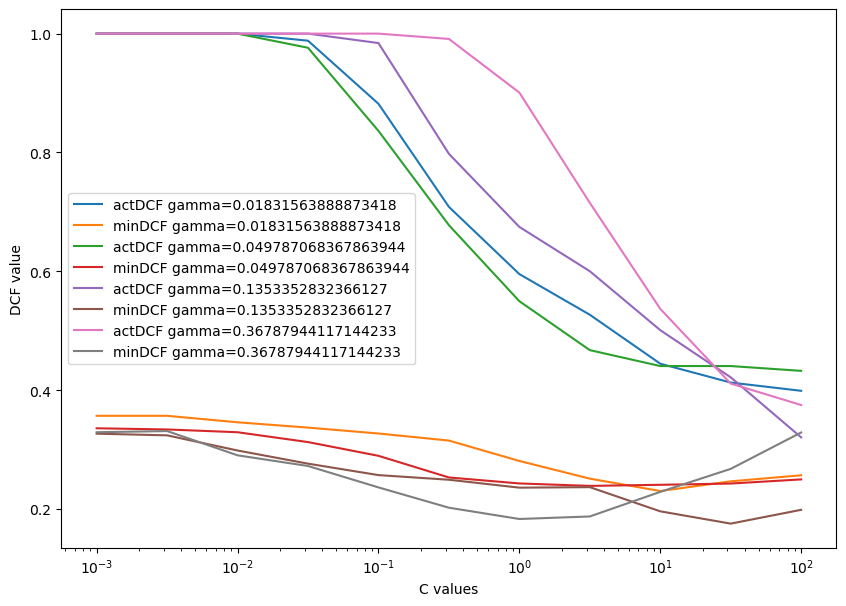

In [29]:
d=2
xi=1
pi_T=0.1
K=0
C=np.logspace(-3, 2, 11)
gammas=np.exp(np.array([-4,-3,-2,-1]))
ZTR=LTR*2-1

best_res=[None, None]  # [C, gamma]
best_dcf=[np.inf, np.inf]  # [minDCF, actDCF]

print(f"================================= K: {K} KRB ==============================================================")
plt.figure(figsize=(10, 7))
for g in gammas:
    dcf=[]
    mindcf=[]
    
    for c in C:
        print(f"================================= c={c} gamma={g} ==============================================================")
        alpha=train_kernel_KRB(K, c, DTR, LTR, xi, g)
        reg_kernel=regular_kernel(KRB(DTR, DVAL, g), xi)
        s=alpha*ZTR @ reg_kernel
        predictions=s > 0
        error_rate=np.mean(predictions != LVAL)
        min_dcf=compute_min_dcf(s, LVAL, pi_T, 1, 1)

        predictions_bayes=get_bayes_decision(s, pi_T, 1, 1)
        act_dcf=DCF_norm(predictions_bayes, LVAL, pi_T, 1, 1)

        dcf.append(act_dcf)
        mindcf.append(min_dcf)

        print(f"Error Rate: {error_rate * 100:.1f}%")
        print(f"DCF min: {min_dcf}")
        print(f"Actual DCF: {act_dcf}\n")

        if (min_dcf < best_dcf[0]) or (min_dcf == best_dcf[0] and act_dcf < best_dcf[1]):
            best_dcf[0]=min_dcf
            best_dcf[1]=act_dcf
            best_res[0]=c
            best_res[1]=g

    plt.plot(C, dcf, label=f'actDCF gamma={g}')
    plt.plot(C, mindcf, label=f'minDCF gamma={g}')

plt.xscale('log')
plt.legend()
plt.xlabel("C values")
plt.ylabel("DCF value")

print(
    f"Migliore combinazione: C={best_res[0]}, gamma={best_res[1]}, "
    f"minDCF={best_dcf[0]}, actDCF={best_dcf[1]}"
)

Salviamo il risultato migliore che abbiamo, sempre perchè ci servirà dopo

In [10]:
d=2
xi=1
pi_T=0.1
K=0
c=31.622776601683793
g=0.1353352832366127
ZTR=LTR*2-1
alpha=train_kernel_KRB(K, c, DTR, LTR, xi, g)
reg_kernel=regular_kernel(KRB(DTR, DVAL, g), xi)
score_svm_poly=alpha*ZTR @ reg_kernel


np.save('llr/score_svm_best.npy', score_svm_poly)

Primal Loss : 12098.69532520933 - Dual Loss : 12098.64798933205
